# Solow Model

Pablo Winant

> **Prerequisites**
>
> This tutorial refers to the lecture on the [convergence of
> sequences](../lectures/convergence/).
>
> Also, make sure you went through the [Julia
> Basics](./Julia_Basics.qmd) before.

# Tutorial: Convergence

### Solow Model

A representative agent uses capital $k_t$ to produce $y_t$ using the
following production function:

$$y_t = k_t^{\alpha}$$

He chooses to consume an amount $c_t \in ]0, y_t]$ and invests what
remains:

$$i_t = y_t - c_t$$

He accumulates capital $k_t$ according to:

$$k_{t+1} = \left( 1-\delta \right) k_{t} + i_{t}$$

where $\delta$ is the depreciation rate and $i_t$ is the amount
invested.

The goal of the representative agent is to maximize:

$$\sum_{t\geq 0} \beta^t U(c_t)$$

where $U(x)=\frac{x^{1-\gamma}}{1-\gamma}$ and $\beta<1$ is the discount
factor.

For now, we ignore the objective and assume that the saving rate
$s=\frac{c_t}{y_t}$ is constant over time.

**Create a `NamedTuple` to hold parameter values $\beta=0.96$,
$\delta=0.1$, $\alpha=0.3$, $\gamma=4$.**

In [3]:
model = (; # named arguments are introduced by ;
    α=0.3,
    β=0.96,
    γ=4,
    δ=0.1,
    s=0.2
)

(α = 0.3, β = 0.96, γ = 4, δ = 0.1, s = 0.2)

**Write down the formula of function $f$ such that $k_{t+1}$:
$k_{t+1} = f(k_t)$.**

$k_{t+1} = (1-\delta) k_{t} + s k_t^{\alpha}$

**Define a function `f(k::Float64, p::NamedTuple)::Float64` to represent
$f$ for a given calibration**

In [4]:
function f(k, model)
    # named argument unpacking
    (;s,α,δ) = model
    y = k^α
    i = s*y
    K = k*(1-δ) + i
end

f (generic function with 1 method)

In [25]:
@time f(1.0, model)

  0.000006 seconds (1 allocation: 16 bytes)


1.1

**Write a function
`simulate(k0::Float64, T::Int, p::NamedTuple)::Vector{Float64}` to
compute the simulation over `T` periods starting from initial capital
level `k0`.**

In [73]:
# without preallocation: grow the vector as we go
function simulate(k0, T, p)
    res = [k0]
    for t=1:T
        k = res[end] # last element
        K = f(k, p)
        push!(res, K)   # exclamation mark: arguments are mutated (/modified)
    end
    return res
end

simulate (generic function with 1 method)

In [74]:
@time simulate(1.0, 40, model)

  0.009545 seconds (6.26 k allocations: 302.250 KiB, 99.76% compilation time)


41-element Vector{Float64}:
 1.0
 1.1
 1.195801151884219
 1.2872430129191352
 1.3742574618933996
 1.456845771393547
 1.5350611815735393
 1.6089955116075123
 1.6787687913320717
 1.7445211874595348
 1.8064066954927231
 1.8645882046429378
 1.9192336394951053
 ⋮
 2.458182902790523
 2.4743121100034533
 2.4893428421830657
 2.5033478018377444
 2.516395180668215
 2.528548894721841
 2.539868814478072
 2.550410988577142
 2.5602278602378736
 2.5693684756833584
 2.577878684115585
 2.5858013289604305

In [75]:
# with preallocation
function simulate(k0, T, p)
    res = zeros(T+1)
    res[1] = k0
    # k = k0
    for t=1:T
        K = f(k0, p)
        k0 = K
        res[t+1] = K   
    end
    return res
end

simulate (generic function with 1 method)

In [34]:
@time simulate(1.0, 40, model)

  0.011924 seconds (8.04 k allocations: 403.898 KiB, 99.62% compilation time)


41-element Vector{Float64}:
 1.0
 1.1
 1.195801151884219
 1.2872430129191352
 1.3742574618933996
 1.456845771393547
 1.5350611815735393
 1.6089955116075123
 1.6787687913320717
 1.7445211874595348
 1.8064066954927231
 1.8645882046429378
 1.9192336394951053
 ⋮
 2.458182902790523
 2.4743121100034533
 2.4893428421830657
 2.5033478018377444
 2.516395180668215
 2.528548894721841
 2.539868814478072
 2.550410988577142
 2.5602278602378736
 2.5693684756833584
 2.577878684115585
 2.5858013289604305

**Make a nice plot to illustrate the convergence. Do we get convergence
from any initial level of capital?**

In [36]:
using Plots

In [38]:
sim = simulate(1.0, 40, model) ; 

In [44]:
using LaTeXStrings

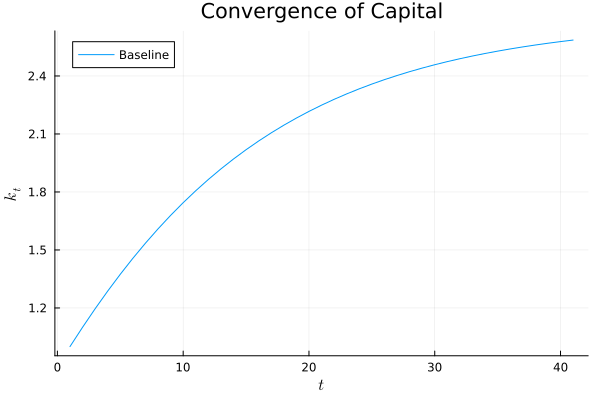

In [47]:
plot(sim, 
    title="Convergence of Capital",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)

In [ ]:
# different levels of capital

In [62]:
k0_vec = [0.5, 1.0, 1.5, 2.0]
# vector comprehension
sims = [ simulate(k, 100, model) for k in k0_vec]

4-element Vector{Vector{Float64}}:
 [0.5, 0.6124504792712471, 0.7238493517042889, 0.832984403877418, 0.9390166705127817, 1.041375090175603, 1.139684956743144, 1.233717469453318, 1.3233531316502873, 1.40855461086888  …  2.688124717954504, 2.688381961924404, 2.688621205942895, 2.6888437090435797, 2.6890506422578495, 2.68924309475745, 2.6894220795694443, 2.689588538893184, 2.689743349046873, 2.6898873250694084]
 [1.0, 1.1, 1.195801151884219, 1.2872430129191352, 1.3742574618933996, 1.456845771393547, 1.5350611815735393, 1.6089955116075123, 1.6787687913320717, 1.7445211874595348  …  2.689166098397878, 2.689350471394512, 2.6895219419408285, 2.689681412713881, 2.689829723270148, 2.6899676544549416, 2.6900959325043807, 2.69021523286128, 2.6903261837248396, 2.6904293693526475]
 [1.5, 1.5758693870913711, 1.6475201583781263, 1.7150841935587584, 1.7787098808849766, 1.8385565989758454, 1.8947904001991414, 1.9475806400433953, 1.9970973557459901, 2.0435092411105487  …  2.690038701794708, 2.6901620075

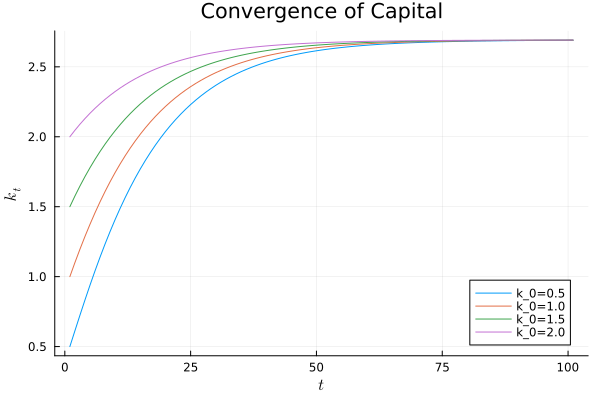

In [63]:
# keep a name for the graph
pl = plot(
    title="Convergence of Capital",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)
# # ! modify the graph
# plot!(pl, sims[1])
# plot!(pl, sims[2])
# plot!(pl, sims[3])
# i = 0
# for sim in sims
#     i += 1
#     k0 = k0_vec[i]
#     plot!(pl, sim, label="k_0=$k0")
# end
for (k0, sim) in zip(k0_vec, sims)
    plot!(pl, sim, label="k_0=$k0")
end
pl

In [76]:
# what is the effect of saving?
sim = simulate(1.5, 100, model)
sim_low = simulate(1.5, 100, merge(model, (;s=0.1)))   # savings are lower
sim_high = simulate(1.5, 100, merge(model, (;s=0.3)))   # savings are higher

101-element Vector{Float64}:
 1.5
 1.6888040806370568
 1.8709947366777304
 2.04592398272588
 2.213198980498043
 2.372618107221001
 2.5241234877029664
 2.6677651665478885
 2.8036737255004165
 2.9320391584470253
 3.0530944639896918
 3.1671028452939014
 3.2743477004381054
 ⋮
 4.79791668478678
 4.798341502230525
 4.798736593342194
 4.799104037493633
 4.799445768699507
 4.799763585765421
 4.800059161729312
 4.8003340526450895
 4.800589705754132
 4.800827467087131
 4.801048588535836
 4.801254234431537

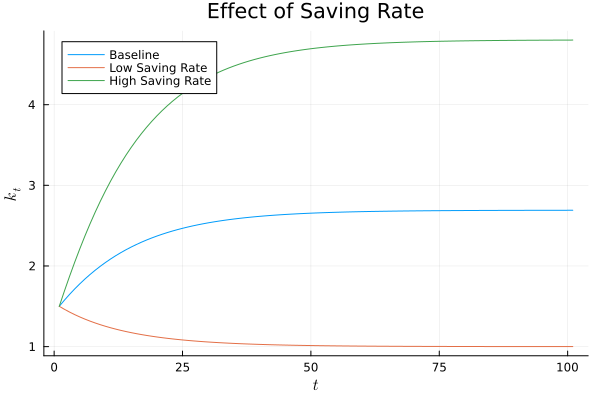

In [77]:
pl = plot(
    title="Effect of Saving Rate",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)
plot!(sim; label="Baseline")
plot!(sim_low; label="Low Saving Rate")
plot!(sim_high; label="High Saving Rate")

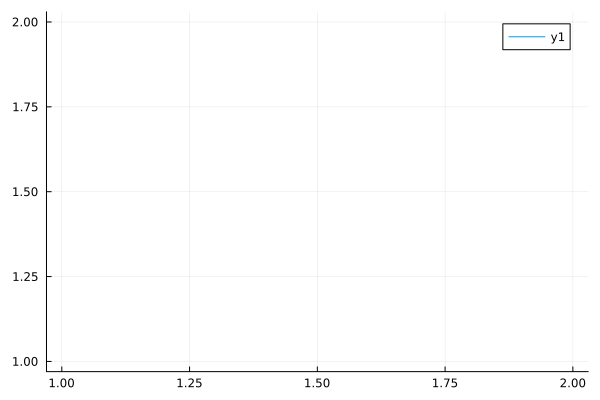

In [82]:
plot([simulate(1.5, 1000, merge(model, (;s=s_)))[end] for s_ = range(0.1, 0.3)])

**Suppose you were interested in using `f` to compute the steady-state.
What would you propose to measure convergence speed? To speed-up
convergence? Implement these ideas.**

In [ ]:
# your code here